In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_attentions=True,
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6429.72it/s]

Ready!


In [2]:
text = "The king and queen ruled the kingdom with power"
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

qkv_activations = {}

def make_hook(layer_idx):
    def hook(module, input, output):
        
        qkv_activations[layer_idx] = output.detach()
    return hook

hooks = []
for i in range(12):
    h = model.h[i].attn.c_attn.register_forward_hook(make_hook(i))
    hooks.append(h)

with torch.no_grad():
    outputs = model(**inputs)


for h in hooks:
    h.remove()

print(f"Tokens: {tokens}")
print(f"QKV activation shape (layer 0): {qkv_activations[0].shape}")
print(f"Captured {len(qkv_activations)} layers!")

Tokens: ['The', 'Ġking', 'Ġand', 'Ġqueen', 'Ġruled', 'Ġthe', 'Ġkingdom', 'Ġwith', 'Ġpower']
QKV activation shape (layer 0): torch.Size([1, 9, 2304])
Captured 12 layers!


In [3]:
d = model.config.n_embd  # 768

# Layer 0 ke activations
layer0_qkv = qkv_activations[0][0]  # [9, 2304]

Q_act = layer0_qkv[:, :d]      # [9, 768]
K_act = layer0_qkv[:, d:2*d]   # [9, 768]
V_act = layer0_qkv[:, 2*d:]    # [9, 768]

print(f"Q activations shape: {Q_act.shape}")
print(f"\nPer token stats (Layer 0):")
print(f"\n{'Token':<12} {'Q mean':<10} {'K mean':<10} {'V mean'}")
print("-"*45)

for i, token in enumerate(tokens):
    print(f"{token:<12} {Q_act[i].mean():.4f}     "
          f"{K_act[i].mean():.4f}     "
          f"{V_act[i].mean():.4f}")

Q activations shape: torch.Size([9, 768])

Per token stats (Layer 0):

Token        Q mean     K mean     V mean
---------------------------------------------
The          -0.0419     0.0309     -0.0024
Ġking        -0.1162     0.0547     0.0104
Ġand         -0.0612     0.0442     0.0188
Ġqueen       -0.1016     0.0664     0.0170
Ġruled       -0.0672     0.0150     0.0138
Ġthe         -0.0853     0.0037     0.0139
Ġkingdom     -0.0886     0.0678     0.0176
Ġwith        -0.0987     0.0272     0.0266
Ġpower       -0.0596     0.0383     0.0089


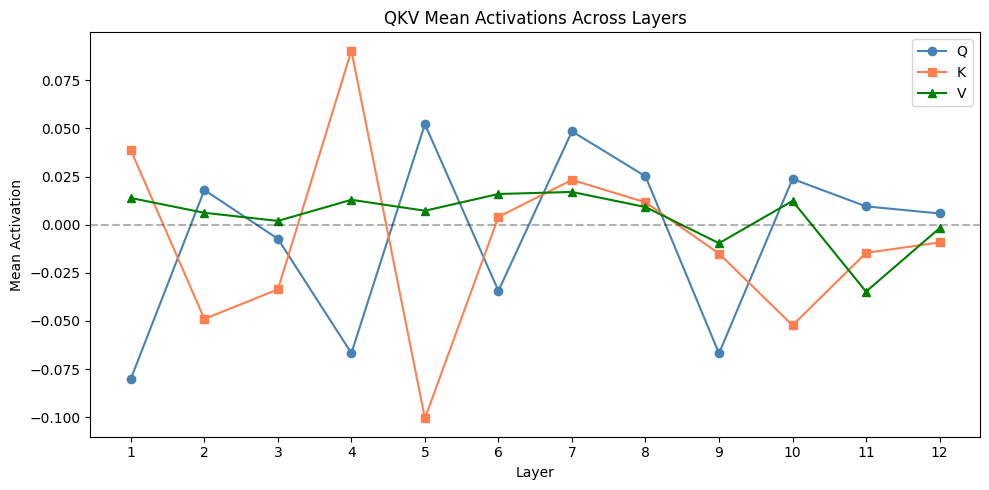

In [4]:
q_means, k_means, v_means = [], [], []

for layer_idx in range(12):
    qkv = qkv_activations[layer_idx][0]
    Q   = qkv[:, :d]
    K   = qkv[:, d:2*d]
    V   = qkv[:, 2*d:]
    
    q_means.append(Q.mean().item())
    k_means.append(K.mean().item())
    v_means.append(V.mean().item())

fig, ax = plt.subplots(figsize=(10, 5))

x = range(1, 13)
ax.plot(x, q_means, marker='o', label="Q", color="steelblue")
ax.plot(x, k_means, marker='s', label="K", color="coral")
ax.plot(x, v_means, marker='^', label="V", color="green")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)

ax.set_xlabel("Layer")
ax.set_ylabel("Mean Activation")
ax.set_title("QKV Mean Activations Across Layers")
ax.legend()
ax.set_xticks(x)

plt.tight_layout()
plt.show()


* Q activations → always negative
* K activations → always positive
* V activations → almost zero
* King and Queen activations are very similar
* This pattern is consistent across all layers
